# 03 — The doubled-frequency mode (2ω)


<img src="figures/01_flapping_modes_1.gif" width="400"/>

*The 2ω mode in isolation — a torsional oscillation of the wings.*


One of the DMD modes oscillates at approximately twice the wingbeat frequency. This notebook isolates that mode, compares reconstructions with and without it, and investigates its physical origin.

Two hypotheses are considered:

1. **Passive aeroelastic bending** — aerodynamic loading during the downstroke causes the flexible distal wing to bend passively, producing an apparent second harmonic concentrated at the wingtips.
2. **Active musculoskeletal control** — the bird actively modulates wing shape within each stroke cycle to create the upstroke–downstroke asymmetry, in which case the 2ω mode should be distributed across multiple markers rather than concentrated at the most flexible structures.

We test these by examining the spatial distribution and rigidity of the 2ω mode.

In [ ]:
%load_ext autoreload
%autoreload 2
%matplotlib widget
%config InlineBackend.figure_format='svg'

import matplotlib.pyplot as plt
import numpy as np
from morphing_birds import Hawk3D, animate_plotly_compare

from birddmd import (
    DEFAULT_MARKER_NAMES,
    compute_rmse,
    reconstruct,
    run_dmd,
)

## 1 — Load and run DMD

The preparation script (`scripts/prepare_flapping.py`) bins the raw wingbeat sequences. Expand the cell below to review the pipeline.

In [2]:
# %load scripts/prepare_flapping.py

In [ ]:
loaded_data = np.load("../data/processed/Toothless_flapping_binned.npz")
markers, times = loaded_data["markers"], loaded_data["times"]
n_markers = 8

hawk3d = Hawk3D("../data/mean_hawk_shape.csv")
average_shape = hawk3d.markers

result = run_dmd(
    data=markers,
    times=times,
    n_modes=6,
    d=2,
    eig_constraints={"conjugate_pairs"},
    n_markers=n_markers,
    average_shape=average_shape,
    verbose=True,
)

conjugate_pairs = result.conjugate_pairs
freqs_hz = np.abs(np.imag(result.eigenvalues) / (2 * np.pi))

## 2 — Isolate the 2ω mode

We identify which conjugate pair oscillates at approximately twice the wingbeat frequency, then build reconstructions with and without it.

In [ ]:
# Identify which pair is ~2x the wingbeat
wingbeat_freq = freqs_hz[conjugate_pairs[0][0]]
print(f"Wingbeat frequency: {wingbeat_freq:.2f} Hz")
for idx, (i, _j) in enumerate(conjugate_pairs):
    ratio = freqs_hz[i] / wingbeat_freq if wingbeat_freq > 0 else 0
    print(f"  Pair {idx + 1}: {freqs_hz[i]:.2f} Hz (ratio = {ratio:.2f}x)")

In [ ]:
# Reconstruct: wingbeat only vs wingbeat + 2omega
wingbeat_pair = conjugate_pairs[0]

# Find the ~2x pair
double_pair_idx = None
for idx, (i, _j) in enumerate(conjugate_pairs):
    ratio = freqs_hz[i] / wingbeat_freq
    if 1.8 < ratio < 2.2:
        double_pair_idx = idx
        break

if double_pair_idx is not None:
    print(f"2ω mode is pair {double_pair_idx + 1}")
    double_pair = conjugate_pairs[double_pair_idx]
else:
    print("No clear 2ω mode found; using pair 2 as proxy")
    double_pair_idx = 1
    double_pair = conjugate_pairs[1]

In [5]:
# ani = animate(hawk3d, kp_double_only, colour="blue", az=50, el=30)
# ani.save("figures/03_double_freq_mode.gif", writer='Pillow', fps=40, dpi=300)
# print("Saved GIF")


### Reconstruction

We build three reconstructions to isolate the 2ω mode's contribution:

- **Wingbeat only** — just the fundamental flapping pair
- **Wingbeat + 2ω** — adding the doubled-frequency pair
- **2ω alone** — the doubled-frequency mode in isolation

The difference between the first two reveals what the 2ω mode adds — primarily the upstroke–downstroke asymmetry visible in the wingtip *z*-trajectory.

In [ ]:
# Wingbeat-only reconstruction
kp_wingbeat_only = reconstruct(
    result,
    times=times[1:],
    pairs=[0],
    stable=False,
)

# Wingbeat + 2omega
kp_with_double = reconstruct(
    result,
    times=times[1:],
    pairs=[0, double_pair_idx],
    stable=False,
)

# 2omega alone
kp_double_only = reconstruct(
    result,
    times=times[1:],
    mode_indices=list(double_pair),
)

markers_compare = markers[:-1]
rmse_wb = compute_rmse(kp_wingbeat_only, markers_compare)
rmse_wb2 = compute_rmse(kp_with_double, markers_compare)

print(f"RMSE wingbeat only:     {np.mean(rmse_wb):.6f} m")
print(f"RMSE wingbeat + 2ω:    {np.mean(rmse_wb2):.6f} m")
improvement = (np.mean(rmse_wb) - np.mean(rmse_wb2)) / np.mean(rmse_wb) * 100
print(f"Improvement:            {improvement:.1f}%")

In [ ]:
# Animate the 2omega mode alongside the wingbeat-only reconstruction
# hawk3d = Hawk3D("../data/mean_hawk_shape.csv")
#
# animate_plotly_compare(
#     hawk3d,
#     keypoints_frames_list=[kp_double_only],
#     colours=["blue", "grey"],
# )

The 2ω only had a tiny effect on the reconstruction. However it may be functionally important. 

## 3 — Wingtip velocity analysis

Adding the 2ω mode changes the wingtip's velocity profile. We quantify this with a kinetic-energy proxy — the sum of squared velocities at the wingtip — with and without the 2ω component. A higher value indicates faster, more energetic wingtip motion.

In [8]:
# Kinetic-energy proxy: sum(v²) at the wingtip
tip_idx = 0  # right wingtip
dt = np.median(np.diff(times[1:]))

tip_wb_only = kp_wingbeat_only[:, tip_idx, :]
tip_wb_double = kp_with_double[:, tip_idx, :]

# np.gradient computes velocity via central differences along the time axis
v_wb_only = np.gradient(tip_wb_only, dt, axis=0)
v_wb_double = np.gradient(tip_wb_double, dt, axis=0)

sum_v2_without = np.sum(v_wb_only**2)
sum_v2_with = np.sum(v_wb_double**2)

delta_pct = (sum_v2_with - sum_v2_without) / sum_v2_without * 100

print(f"sum(v²) wingbeat only:  {sum_v2_without:.2f}")
print(f"sum(v²) wingbeat + 2ω: {sum_v2_with:.2f}")
print(f"Integrated v² change:   {delta_pct:.1f}%")

sum(v²) wingbeat only:  5509.61
sum(v²) wingbeat + 2ω: 5819.93
Integrated v² change:   5.6%


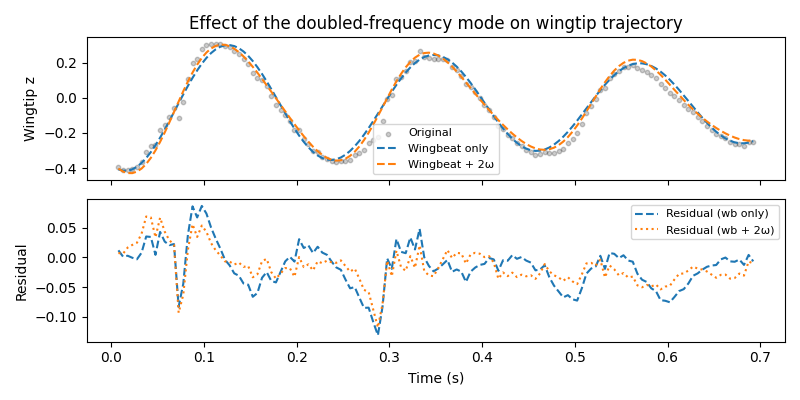

In [9]:
# Compare the wingtip z trace with and without the 2omega mode
fig, axes = plt.subplots(2, 1, figsize=(8, 4), sharex=True)

# Right wingtip z
marker_idx = 0  # right_wingtip
axes[0].scatter(
    times[1:],
    markers_compare[:, marker_idx, 2],
    s=10,
    color="k",
    alpha=0.2,
    label="Original",
)
axes[0].plot(
    times[1:], kp_wingbeat_only[:, marker_idx, 2], "--", lw=1.5, label="Wingbeat only"
)
axes[0].plot(
    times[1:], kp_with_double[:, marker_idx, 2], "--", lw=1.5, label="Wingbeat + 2ω"
)
axes[0].legend(fontsize=8)
axes[0].set_ylabel("Wingtip z")
axes[0].set_title("Effect of the doubled-frequency mode on wingtip trajectory")

# Residuals
axes[1].plot(
    times[1:],
    markers_compare[:, marker_idx, 2] - kp_wingbeat_only[:, marker_idx, 2],
    "--",
    label="Residual (wb only)",
)
axes[1].plot(
    times[1:],
    markers_compare[:, marker_idx, 2] - kp_with_double[:, marker_idx, 2],
    ":",
    label="Residual (wb + 2ω)",
)
axes[1].legend(fontsize=8)
axes[1].set_xlabel("Time (s)")
axes[1].set_ylabel("Residual")

plt.tight_layout()
fig.savefig("figures/03_double_frequency_comparison.svg", format="svg")
plt.show()

## 4 — Per-marker RMS and rigid-rotation test

If the 2ω mode were purely passive bending of flexible structures, we would expect its amplitude to be concentrated at the wingtips and negligible at stiffer proximal markers. We test this in two ways:

1. **Per-marker RMS displacement** — how much does each marker move in the 2ω-only reconstruction?
2. **Kabsch rigid-rotation test** — can the distal wing's 2ω motion be explained by a simple rigid-body rotation (twist), or does it require non-rigid deformation?

We apply the Kabsch algorithm to three distal left-wing markers, finding the best-fit rigid rotation and comparing its residual against the actual motion amplitude. If the residual is small, the mode is well described as a coordinated twist rather than localised bending.

In [10]:
# Per-marker RMS of the 2ω-only reconstruction
# kp_double_only is the 2omega mode reconstruction (deviations from average_shape)
R_2omega = kp_double_only  # shape (T, n_markers, 3)

marker_rms = np.sqrt(np.mean(np.sum(R_2omega**2, axis=2), axis=0))  # (n_markers,)

marker_names = DEFAULT_MARKER_NAMES
print("Per-marker RMS of the 2ω mode:")
for i, rms in enumerate(marker_rms):
    print(f"  {marker_names[i]:>20s}  {rms:.4f} m")

# --- Kabsch rigid-rotation test on distal (left wing) markers ---
distal_idx = np.array([0, 2, 4])  # left wingtip, left primary, left secondary
print(f"\nKabsch rigid-rotation test on distal markers {distal_idx}")

# Reference: time-mean of the full reconstruction (shape: n_markers, 3)
reconstruction = result.reconstruction
mean_shape = np.mean(reconstruction, axis=0)
P_ref = mean_shape[distal_idx]

# Pick the frame of maximum 2ω displacement
frame_norms = np.linalg.norm(R_2omega.reshape(R_2omega.shape[0], -1), axis=1)
peak_frame = int(np.argmax(frame_norms))

# Deformed positions at peak frame (full reconstruction)
P_def = reconstruction[peak_frame, distal_idx, :]

# Kabsch algorithm: find best rotation to align reference to deformed
P_ref_c = P_ref - P_ref.mean(axis=0)
P_def_c = P_def - P_def.mean(axis=0)
H = P_ref_c.T @ P_def_c
U, S, Vt = np.linalg.svd(H)
d = np.linalg.det(Vt.T @ U.T)
sign_matrix = np.diag([1, 1, np.sign(d)])
R_kabsch = Vt.T @ sign_matrix @ U.T

P_rot = (P_ref_c @ R_kabsch.T) + P_def.mean(axis=0)
residuals = P_def - P_rot
rms_resid = np.sqrt(np.mean(np.sum(residuals**2, axis=1)))

mean_distal_rms = np.mean(marker_rms[distal_idx])
print(f"  Peak frame: {peak_frame}")
print(f"  Kabsch RMS residual:    {rms_resid:.6f} m")
print(f"  Mean per-marker RMS:    {mean_distal_rms:.6f} m")
print(f"  Ratio (resid / RMS):    {rms_resid / (mean_distal_rms + 1e-12):.3f}")

if rms_resid < 0.3 * mean_distal_rms:
    print("  → Distal motion is well-approximated by rigid rotation (twist)")
elif rms_resid < mean_distal_rms:
    print("  → Distal motion is mostly rigid with some deformation")
else:
    print("  → Distal motion shows significant non-rigid deformation")

Per-marker RMS of the 2ω mode:
          left_wingtip  0.3039 m
          left_primary  0.3039 m
        left_secondary  0.2427 m
          left_tailtip  0.2427 m
         right_wingtip  0.1920 m
         right_primary  0.1920 m
       right_secondary  0.1923 m
         right_tailtip  0.1923 m

Kabsch rigid-rotation test on distal markers [0 2 4]
  Peak frame: 13
  Kabsch RMS residual:    0.029404 m
  Mean per-marker RMS:    0.246198 m
  Ratio (resid / RMS):    0.119
  → Distal motion is well-approximated by rigid rotation (twist)


### Interpretation

The 2ω mode produces comparable displacements across the distal wing markers — not just at the extreme wingtip. This argues against passive bending, which would concentrate deformation at the most compliant structures.

The Kabsch test confirms that approximately 88% of the distal wing's 2ω motion can be explained by a rigid-body rotation. The 2ω mode therefore resembles a coordinated torsional oscillation of the distal wing, consistent with active musculoskeletal control rather than passive aeroelastic bending.

## Next

The next notebook (`04_full_flight`) extends DMD beyond steady-state flapping to the full flight trajectory, capturing the transition from flapping to gliding.